# Europa Raypath Simulator

In [1]:
# imports
import sys, os
sys.path.append("../../src")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from surface import *
from source import *
from simulator import *
from focus import *
from terrain import *
from util import mag_to_db

GPU's detected. Enabling CUDA compute


## Specular Point Target

*Using a $3\degree$ wide boxcar*

| Transit | Traces | Altitude | Target Depth | Polarization | f₀ | Power |
|---------|--------|----------|---------------|--------------|----------|-----------|
| 30 km   | 300    | 25 km    | 1 km          | v            | 9 MHz    | 11.75 W   |

| Subsurface Gain | Surface Gain | Rx Opening | Rx Window | Rx Sampling | ε₁ | ε₂  | σ₁ | σ₂       |
|------------------|---------------|------------|------------|--------------|----|-----|-----|-----------|
| 80 dB            | 76 dB         | 22.5 km      | 10 km      | 48 MHz       | 1  | 3.15 | 0 S | 10⁻⁶ S   |


In [2]:
# terrain extent
xmin, xmax =  -6e3,  6e3
ymin, ymax =  -1e3,  1e3

# facet into
fs   = 5
dims = (400, 400)

terrain = Terrain(xmin, xmax, ymin, ymax, fs)
terrain.gen_flat(0)

In [3]:
# generate linspace of sources
ss = source_linspace('x', -5e3, 5e3, 0, 10e3, 200, 9e6, 1e6)

# target location
t = (0, 0, -1000)   # target location (x, y, z)

par = {
    'surf_gain':77,
    'rx_window_offset':7.5e3,
    'rx_window_m':10e3,
    'aspect':0.5
}

In [4]:
par['surf_gain'] = 76
rdrgrm, time = run_sim_terrain(terrain, dims, ss, t, reflect=True, polarization='v', sltrng=False, pt_response="gaussian", refl_center=True, show=False, par=par, nsmpl=1601)
np.save("rdrgrm.npy", rdrgrm)

12181.467510515387(0.5%) | ETA: 00:00     
12159.075954009822(1.0%) | ETA: 00:12     
12136.86612049404 (1.5%) | ETA: 00:11     
12114.83909933329 (2.0%) | ETA: 00:11     
12092.995979542862(2.5%) | ETA: 00:11     
12071.33784960426 (3.0%) | ETA: 00:11     
12049.86579727822 (3.5%) | ETA: 00:10     
12028.580909414646(4.0%) | ETA: 00:10     
12007.484271759462(4.5%) | ETA: 00:10     
11986.576968758422 (5.0%) | ETA: 00:10     
11965.860083357893 (5.5%) | ETA: 00:10     
11945.334696802667 (6.0%) | ETA: 00:10     
11925.001888430856 (6.5%) | ETA: 00:10     
11904.862735465850 (7.0%) | ETA: 00:10     
11884.918312805465 (7.5%) | ETA: 00:10     
11865.169692808267 (8.0%) | ETA: 00:10     
11845.617945077167 (8.5%) | ETA: 00:10     
11826.264136240290 (9.0%) | ETA: 00:10     
11807.109329729265 (9.5%) | ETA: 00:09     
11788.154585554890 (10.0%) | ETA: 00:09     
11769.400960080322 (10.5%) | ETA: 00:09     
11750.849505791830 (11.0%) | ETA: 00:09     
11732.501271067184 (11.5%) | ETA: 00:0

### Focus

In [5]:
sx = [s.coord[0] for s in ss]
sz = ss[0].coord[2]
c1 = 299792458
c2 = c1 / np.sqrt(3.15)

sampl = 48e6   # sampling rate [MHz]
wavlen = 33.3  # wavelength    [m]

rb = int((par['rx_window_m'] / c1) / (1 / sampl))
dm = c1 / (sampl)

In [6]:
sltrng   = est_slant_range(sx, sz, t[0], t[2], c1, c2)
sltrng_t = 2 * 10**6 * sltrng / c1
slt_rb   = ((sltrng - par['rx_window_offset']) // dm).astype(int)

In [7]:
k = (2 * np.pi) / wavlen
match_filter = np.exp(-2j * k * sltrng)

In [8]:
focused = focus_jit(rdrgrm, slt_rb, match_filter, rb)

### Generate Figure

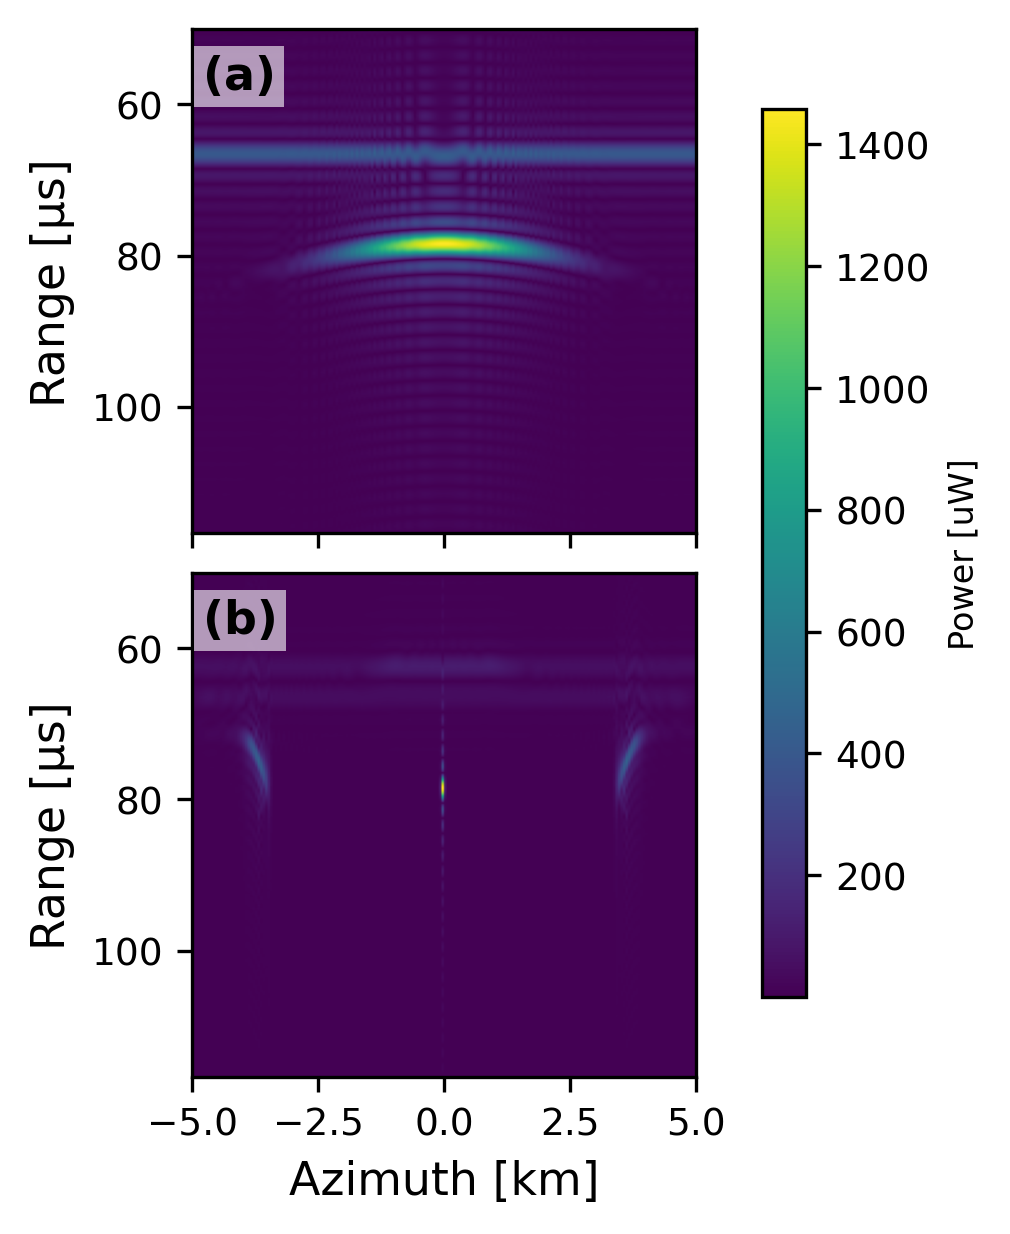

In [9]:
extent = (-5, 5, 2*((par['rx_window_offset'] + par['rx_window_m'])/c1)*10**6, 2*(par['rx_window_offset']/c1)*10**6) 
fig, ax = plt.subplots(2, 1, figsize=(4, 4), constrained_layout=True, dpi=300, sharex=True)
im0 = ax[0].imshow(np.abs(rdrgrm)*1e6, cmap="viridis", aspect=par['aspect']*0.3, extent=extent) 
im1 = ax[1].imshow(np.abs(focused)*1e6, cmap="viridis", aspect=par['aspect']*0.3, extent=extent) 
labels = ["(a)", "(b)"] 
for a, label in zip(ax, labels): 
    a.set_ylabel("Range [µs]", fontsize=11) 
    a.tick_params(axis="both", which="major", labelsize=9, direction="out") 
    a.tick_params(axis="both", which="minor", direction="out") 
    a.text(0.02, 0.95, label, transform=a.transAxes, fontsize=11, fontweight="bold", va="top", ha="left", color="black", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)) 
ax[1].set_xlabel("Azimuth [km]", fontsize=11) 
cbar = fig.colorbar(im1, ax=ax, orientation="vertical", fraction=0.05, pad=0.04) 
cbar.set_label("Power [uW]", fontsize=8) 
cbar.ax.tick_params(labelsize=9) 
plt.savefig("focusedAbs.png", dpi=300, bbox_inches="tight") 
plt.show()
plt.close()

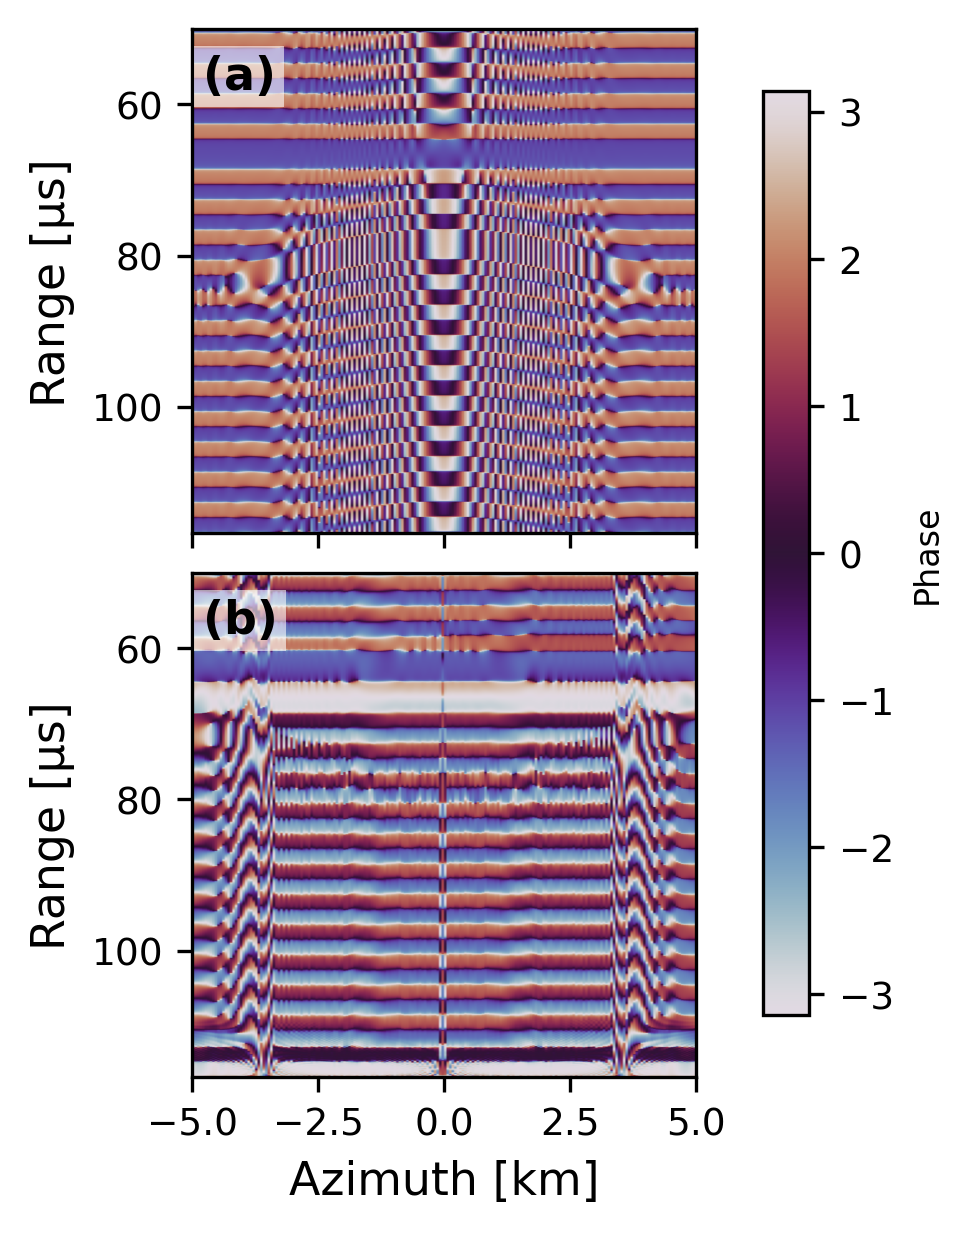

In [10]:
extent = (-5, 5, 2*((par['rx_window_offset'] + par['rx_window_m'])/c1)*10**6, 2*(par['rx_window_offset']/c1)*10**6) 
fig, ax = plt.subplots(2, 1, figsize=(4, 4), constrained_layout=True, dpi=300, sharex=True)
im0 = ax[0].imshow(np.angle(rdrgrm), cmap="twilight", aspect=par['aspect']*0.3, extent=extent) 
im1 = ax[1].imshow(np.angle(focused), cmap="twilight", aspect=par['aspect']*0.3, extent=extent) 
labels = ["(a)", "(b)"] 
for a, label in zip(ax, labels): 
    a.set_ylabel("Range [µs]", fontsize=11) 
    a.tick_params(axis="both", which="major", labelsize=9, direction="out") 
    a.tick_params(axis="both", which="minor", direction="out") 
    a.text(0.02, 0.95, label, transform=a.transAxes, fontsize=11, fontweight="bold", va="top", ha="left", color="black", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)) 
ax[1].set_xlabel("Azimuth [km]", fontsize=11) 
cbar = fig.colorbar(im1, ax=ax, orientation="vertical", fraction=0.05, pad=0.04) 
cbar.set_label("Phase", fontsize=8) 
cbar.ax.tick_params(labelsize=9) 
plt.savefig("focusedPhase.png", dpi=300, bbox_inches="tight") 
plt.show()
plt.close()

In [11]:
plt.imshow(np.angle(rdrgrm), aspect='auto', cmap='twilight',
        extent=extent)
plt.colorbar(label="Phase")
plt.xlabel("Azimuth [km]")
plt.ylabel("Range [us]")
plt.savefig('rdrphase.png')
plt.close()